In [ ]:
!pip install pandas numpy pywavelets matplotlib
!pip install --user scikit-learn
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for tensorflow[and-cuda] from https://files.pythonhosted.org/packages/cf/24/271e77c22724f370c24c705f394b8035b4d27e4c2c6339f3f45ab9b8258e/tensorflow-2.18.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for tensorflow-intel==2.18.0 from https://files.pythonhosted.org/packages/76/ad/fa6c508a15ff79cb5409294c293388e0999b7d480f84b65e4287277434fe/tensorflow_intel-2.18.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for nvidia-cublas-cu12==12.5.3.2 from https://files.pythonhosted.org/packages/50/18/d32d9ea61a6df42b3887b4a8acb6edcf81bd2cf787c8dbf759f1e63f1414/nvidia_cublas_cu12-12.5.3.2-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for nvidia-cuda-cupti-cu12==12.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import os
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import math

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
e1 = pd.read_excel(r"C:\Users\ma.benavidess1\Downloads\EICH101.xlsx")

# Filtrar registros según ORIG_RAW_VOLUME
e1 = e1[e1["ORIG_RAW_VOLUME"] <= 60]

# Convertir EFFECTIVE_DATE a formato de fecha
e1["EFFECTIVE_DATE"] = pd.to_datetime(e1["EFFECTIVE_DATE"], errors='coerce')

# Aplicar normalización Z-score
scaler = StandardScaler()
columns_to_normalize = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE","TEMPERATURE","PRESSURE","ORIG_PRESSURE","RAW_VOLUME","ORIG_RAW_VOLUME"]  # Ajusta si necesitas más
e1[columns_to_normalize] = scaler.fit_transform(e1[columns_to_normalize])

# Guardar el resultado en un CSV en la misma carpeta donde está el pipeline
output_path = "datos_procesados_empresa1.csv"
e1.to_csv(output_path, index=False)

print(f"Archivo guardado en {output_path}")

Archivo guardado en datos_procesados_empresa1.csv


In [ ]:
# SCalcular el percentil 99 global para evitar que las anomalías dominen
global_max = np.percentile(e1["ORIG_RAW_VOLUME"], 99)
 
# Aplicar normalización dividiendo por ese valor máximo
e1["ORIG_RAW_VOLUME_NORM"] = e1["ORIG_RAW_VOLUME"] / global_max
e1["ORIG_RAW_VOLUME_NORM"] = np.clip(e1["ORIG_RAW_VOLUME_NORM"], 0, 1)

In [27]:
# Crear la carpeta donde se guardarán las imágenes
output_folder = r"c:\Users\ma.benavidess1\Downloads\ProyectoGradoGEB\imagenes_diarias"
os.makedirs(output_folder, exist_ok=True)


In [26]:
# Escalas para la Transformada Wavelet Continua (CWT)
scales = np.arange(1, 128)

# Recorrer el archivo secuencialmente
e1_sorted = e1.sort_values(by="EFFECTIVE_DATE")
 
# Obtener los años únicos en el DataFrame
years = e1_sorted['EFFECTIVE_DATE'].dt.year.unique()
 
for year in years:
    e1_year = e1_sorted[e1_sorted['EFFECTIVE_DATE'].dt.year == year]
    
    # Obtener los días únicos ordenados
    days = sorted(e1_year['EFFECTIVE_DATE'].dt.date.unique())
 
    for day in days:
        e1_day = e1_year[e1_year['EFFECTIVE_DATE'].dt.date == day]
        if not e1_day.empty:
            # Extraer la señal del día (manteniendo valores originales sin escalar)
            signal_day = e1_day['ORIG_RAW_VOLUME'].values
 
            # Aplicar la Transformada Wavelet Continua (CWT) con Morlet
            coefficients, frequencies = pywt.cwt(signal_day, scales, 'morl')
 
            # Crear la figura del escalograma
            plt.figure(figsize=(10, 6))
            plt.imshow(np.abs(coefficients), aspect="auto", cmap="jet",
                       extent=[0, len(signal_day), scales[-1], scales[0]])

            plt.colorbar(label="Magnitud")
            plt.title(f"Escalograma - Año {year} - Día {day}", fontsize=12, fontweight="bold")
            plt.xlabel("Horas del Día")
            plt.ylabel("Escala")
 
            # Guardar la imagen
            filename = f"Año{year}_Día{day}.png".replace(" ", "")
            filepath = os.path.join(output_folder, filename)
            plt.savefig(filepath, dpi=300, bbox_inches="tight")
            plt.close()
 
# Listar los archivos generados
generated_files = os.listdir(output_folder)

print("Ejemplo de archivos generados:", generated_files[:10])  # Mostrar solo los primeros 10 archivos como muestra

Ejemplo de archivos generados: ['Año2018_Día2018-09-03.png', 'Año2018_Día2018-09-04.png', 'Año2018_Día2018-09-05.png', 'Año2018_Día2018-09-06.png', 'Año2018_Día2018-09-07.png', 'Año2018_Día2018-09-08.png', 'Año2018_Día2018-09-09.png', 'Año2018_Día2018-09-10.png', 'Año2018_Día2018-09-11.png', 'Año2018_Día2018-09-12.png']


Found 1370 images belonging to 2 classes.
Found 1311 images belonging to 2 classes.
Found 645 images belonging to 2 classes.
Total imágenes en entrenamiento: 1370
Total imágenes en validación: 1311
Total imágenes en prueba: 645

Entrenando modelo: MobileNetV2


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 964s 22s/step - accuracy: 0.6875 - loss: 0.5719 - val_accuracy: 0.7971 - val_loss: 0.4305
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 613s 14s/step - accuracy: 0.7942 - loss: 0.4282 - val_accuracy: 0.7735 - val_loss: 0.4480
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7989 - loss: 0.4293 - val_accuracy: 0.8330 - val_loss: 0.3729
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.8225 - loss: 0.3909 - val_accuracy: 0.8505 - val_loss: 0.3537
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8333 - loss: 0.3655 - val_accuracy: 0.8513 - val_loss: 0.3437
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.8429 - loss: 0.3462 - val_accuracy: 0.8596 - val_loss: 0.3322
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.8540 - loss: 0.3408 - val_accuracy: 0.8520 - val_loss: 0.3336
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 887s 21s/step - accuracy: 0.8379 - loss: 0.3556 - val_accuracy: 0.8589 

Precisión de MobileNetV2 en el conjunto de prueba: 71.16%

Guardando datos de validación y prueba para MobileNetV2...

✅ Datos guardados en X_val_MobileNetV2.npy, y_val_MobileNetV2.npy, X_test_MobileNetV2.npy y y_test_MobileNetV2.npy

Evaluando métricas para MobileNetV2...

41/41 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step
Matriz de Confusión:
 [[552  98]
 [ 89 572]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86       650
           1       0.85      0.87      0.86       661

    accuracy                           0.86      1311
   macro avg       0.86      0.86      0.86      1311
weighted avg       0.86      0.86      0.86      1311

F1-Score: 0.8573458513429544
Precisión: 0.8574117528040033
Error Tipo I (Falsos Positivos): 98
Error Tipo II (Falsos Negativos): 89


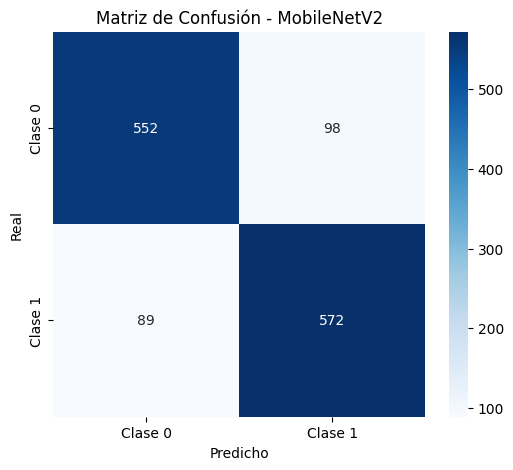


Entrenando modelo: ResNet34
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.5364 - loss: 0.7077 - val_accuracy: 0.6590 - val_loss: 0.6451
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 170s 4s/step - accuracy: 0.6090 - loss: 0.6516 - val_accuracy: 0.7132 - val_loss: 0.6117
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 596s 14s/step - accuracy: 0.6619 - loss: 0.6114 - val_accuracy: 0.6987 - val_loss: 0.5956
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.6618 - loss: 0.6035 - val_accuracy: 0.7368 - val_loss: 0.5519
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 371s 9s/step - accuracy: 0.7445 - loss: 0.5430 - val_accuracy: 0.6255 - val_loss: 0.6107
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.6769 - loss: 0.5794 - val_accuracy: 0.7079 - val_loss: 0.5531
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1748s 42s/step - accuracy: 0.7274 - loss: 0.5253 - val_accuracy: 0.7346 - val_loss: 0.5180
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.7586 - loss: 0

Precisión de ResNet34 en el conjunto de prueba: 64.34%

Guardando datos de validación y prueba para ResNet34...

✅ Datos guardados en X_val_ResNet34.npy, y_val_ResNet34.npy, X_test_ResNet34.npy y y_test_ResNet34.npy

Evaluando métricas para ResNet34...

41/41 ━━━━━━━━━━━━━━━━━━━━ 624s 14s/step
Matriz de Confusión:
 [[531 119]
 [167 494]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       650
           1       0.81      0.75      0.78       661

    accuracy                           0.78      1311
   macro avg       0.78      0.78      0.78      1311
weighted avg       0.78      0.78      0.78      1311

F1-Score: 0.7816203150484539
Precisión: 0.7834981945236221
Error Tipo I (Falsos Positivos): 119
Error Tipo II (Falsos Negativos): 167


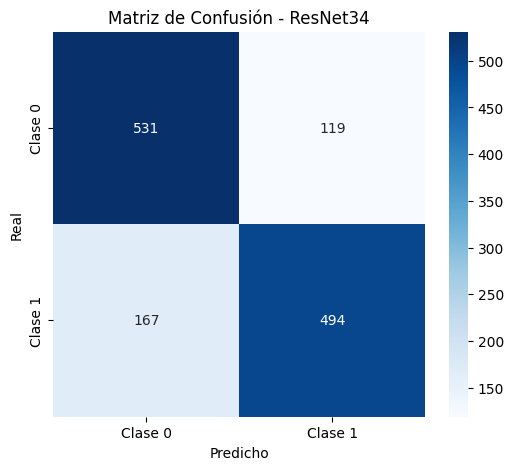


Entrenando modelo: VGG16bn
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2966s 69s/step - accuracy: 0.5510 - loss: 1.4521 - val_accuracy: 0.7551 - val_loss: 0.6184
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2250s 53s/step - accuracy: 0.7614 - loss: 0.5850 - val_accuracy: 0.8085 - val_loss: 0.5415
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1388s 32s/step - accuracy: 0.8062 - loss: 0.5403 - val_accuracy: 0.8032 - val_loss: 0.5248
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 332s 8s/step - accuracy: 0.8223 - loss: 0.5232 - val_accuracy: 0.8474 - val_loss: 0.5060
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 370s 9s/step - accuracy: 0.8446 - loss: 0.5221 - val_accuracy: 0.8261 - val_loss: 0.4914
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 400s 9s/step - accuracy: 0.8392 - loss: 0.4981 - val_accuracy: 0.8696 - val_loss: 0.4867
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 361s 8s/step - accuracy: 0.8493 - loss: 0.4840 - val_accuracy: 0.8421 - val_loss: 0.4682
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 343s 8s/step - accuracy: 0.8466 - loss:

Precisión de VGG16bn en el conjunto de prueba: 77.21%

Guardando datos de validación y prueba para VGG16bn...

✅ Datos guardados en X_val_VGG16bn.npy, y_val_VGG16bn.npy, X_test_VGG16bn.npy y y_test_VGG16bn.npy

Evaluando métricas para VGG16bn...

41/41 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step
Matriz de Confusión:
 [[494 156]
 [ 29 632]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84       650
           1       0.80      0.96      0.87       661

    accuracy                           0.86      1311
   macro avg       0.87      0.86      0.86      1311
weighted avg       0.87      0.86      0.86      1311

F1-Score: 0.8574312710746311
Precisión: 0.8726926521511329
Error Tipo I (Falsos Positivos): 156
Error Tipo II (Falsos Negativos): 29


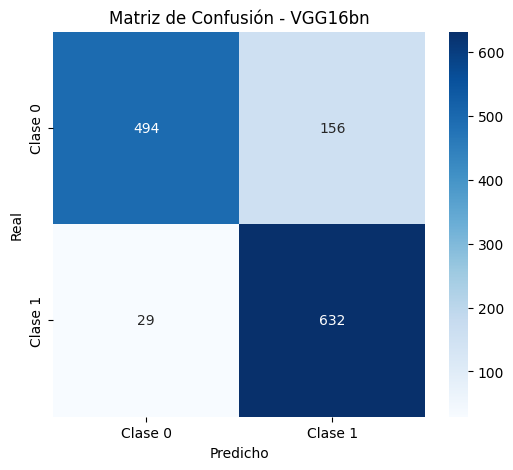

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Parámetros
img_size = (224, 224)  
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/imagenes_diarias"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (70%), validación (20%) y prueba (10%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)  # 20% para validación y prueba

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.33)  # Divide el 20% en 10% validación y 10% prueba

# Generador de entrenamiento (70% de los datos)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

# Generador de validación (20% de los datos)
val_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",  # La primera mitad del 20% restante
    shuffle=False
)

# Generador de prueba (10% de los datos)
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",  # La otra mitad del 20% restante
    shuffle=False
)

print(f"Total imágenes en entrenamiento: {train_generator.samples}")
print(f"Total imágenes en validación: {val_generator.samples}")
print(f"Total imágenes en prueba: {test_generator.samples}")

# Función para construir modelos
def build_model(base_model):
    base_model.trainable = False  
    
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    
    model = build_model(base_model)  

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs
    )

    # Evaluar en conjunto de prueba (final)
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Guardar el modelo
    model.save(f"modelo_anomalias_{name}.h5")  

    # 🚀 Guardar datos de validación y prueba en NumPy
    print(f"\nGuardando datos de validación y prueba para {name}...\n")
    
    X_val = np.concatenate([val_generator[i][0] for i in range(len(val_generator))])
    y_val = np.concatenate([val_generator[i][1] for i in range(len(val_generator))])

    X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])
    y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])

    np.save(f"X_val_{name}.npy", X_val)
    np.save(f"y_val_{name}.npy", y_val)
    np.save(f"X_test_{name}.npy", X_test)
    np.save(f"y_test_{name}.npy", y_test)

    print(f"✅ Datos guardados en X_val_{name}.npy, y_val_{name}.npy, X_test_{name}.npy y y_test_{name}.npy")

    # 🚀 Evaluar métricas con conjunto de prueba
    print(f"\nEvaluando métricas para {name}...\n")

    # Obtener etiquetas reales de validación
    y_val_classes = val_generator.classes  

    # Obtener predicciones del modelo
    y_pred_proba = model.predict(val_generator)  
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()  

    # Matriz de Confusión
    matriz_conf = confusion_matrix(y_val_classes, y_pred)
    print("Matriz de Confusión:\n", matriz_conf)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_val_classes, y_pred))

    # Obtener métricas individuales
    f1 = f1_score(y_val_classes, y_pred, average='weighted')
    precision = precision_score(y_val_classes, y_pred, average='weighted')

    print(f"F1-Score: {f1}")
    print(f"Precisión: {precision}")

    # Extraer valores de la matriz de confusión
    TN, FP, FN, TP = matriz_conf.ravel()

    # Error Tipo I (Falsos Positivos)
    error_tipo_1 = FP

    # Error Tipo II (Falsos Negativos)
    error_tipo_2 = FN

    print(f"Error Tipo I (Falsos Positivos): {error_tipo_1}")
    print(f"Error Tipo II (Falsos Negativos): {error_tipo_2}")

    # 📊 Visualizar la Matriz de Confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()


Found 1370 images belonging to 2 classes.
Found 586 images belonging to 2 classes.
Found 586 images belonging to 2 classes.
Total imágenes en entrenamiento: 1370
Total imágenes en validación: 586
Total imágenes en prueba: 586

Entrenando modelo: MobileNetV2
Epoch 1/10
43/43 [==============================] - 136s 3s/step - loss: 0.6143 - accuracy: 0.6861 - val_loss: 0.6666 - val_accuracy: 0.6365
Epoch 2/10
43/43 [==============================] - 127s 3s/step - loss: 0.4444 - accuracy: 0.7978 - val_loss: 0.7689 - val_accuracy: 0.6297
Epoch 3/10
43/43 [==============================] - 136s 3s/step - loss: 0.4401 - accuracy: 0.7861 - val_loss: 0.5903 - val_accuracy: 0.6792
Epoch 4/10
43/43 [==============================] - 138s 3s/step - loss: 0.3969 - accuracy: 0.8175 - val_loss: 0.5667 - val_accuracy: 0.6911
Epoch 5/10
43/43 [==============================] - 128s 3s/step - loss: 0.3730 - accuracy: 0.8314 - val_loss: 0.6056 - val_accuracy: 0.6826
Epoch 6/10
43/43 [===================

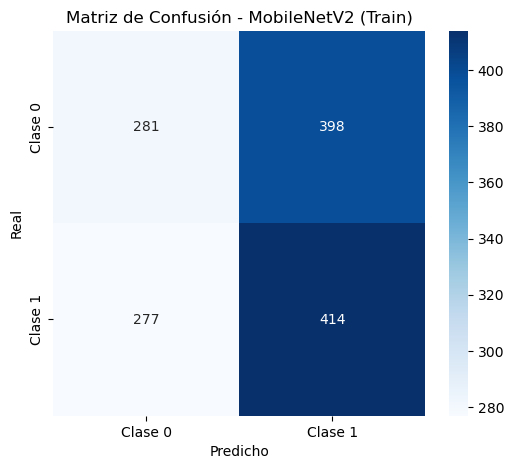

Imágenes clasificadas como falsos positivos en Train: [  1   2   3   6   7   9  11  12  13  15  18  19  21  22  24  26  31  33
  34  35  36  37  38  40  42  44  45  46  47  49  51  53  54  55  57  58
  59  62  63  64  66  67  68  70  72  75  77  81  82  86  87  88  89  90
  91  92  93  94  95  96  97  99 100 101 103 105 106 109 110 111 118 119
 120 122 128 129 130 131 137 138 139 141 142 143 146 147 148 149 150 151
 152 153 155 156 157 160 162 163 165 166 167 168 170 171 172 173 176 178
 179 183 186 187 188 190 191 192 194 196 198 199 201 204 205 206 207 208
 209 210 211 212 214 215 216 217 221 222 223 225 226 228 229 232 233 234
 235 236 241 242 244 246 247 248 250 255 256 258 259 262 263 264 265 266
 267 270 272 273 275 276 278 281 282 285 286 287 289 292 293 296 297 299
 300 301 303 304 307 309 310 312 313 318 319 321 322 323 326 327 330 331
 333 335 336 337 339 341 342 344 348 349 351 352 354 355 360 363 364 365
 366 367 369 371 372 373 374 375 376 377 378 380 383 384 385 386 389 3

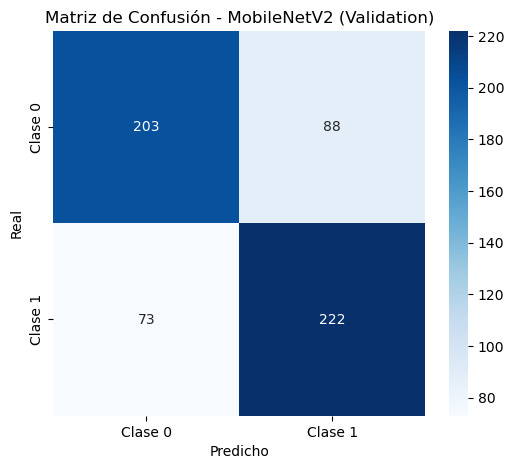

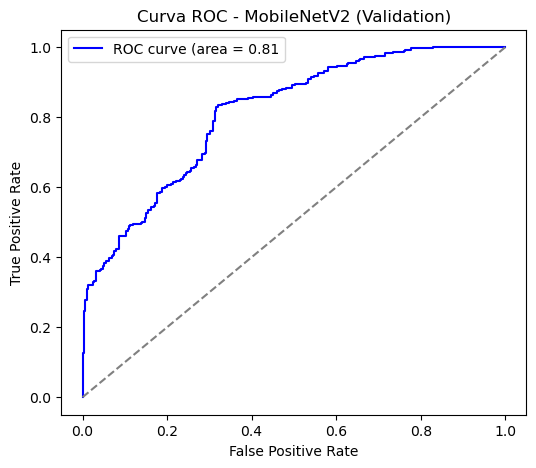

Imágenes clasificadas como falsos positivos en Validation: [  2   3   4   5   6   7   8  11  12  13  16  17  21  22  25  26  28  29
  31  32  35  37  42  44  45  49  52  56  58  62  65  66  71  74  77  85
  89  95  96  97  98 102 104 111 123 125 130 131 135 136 140 150 152 156
 161 168 169 174 175 184 185 186 187 198 199 200 203 204 205 206 207 208
 209 210 211 215 216 220 228 232 233 245 251 252 263 270 281 287]
Imágenes clasificadas como falsos negativos en Validation: [298 306 323 324 331 336 346 348 349 352 357 370 391 393 398 404 405 407
 408 411 418 419 424 428 432 442 448 454 466 470 471 477 478 482 483 487
 488 491 493 495 496 498 499 501 502 503 506 508 512 516 519 520 523 526
 527 528 529 530 533 534 536 537 538 541 542 544 545 546 547 548 549 552
 583]

Evaluando métricas para MobileNetV2 en Test...
19/19 [==============================] - 37s 2s/step
Matriz de Confusión en Test:
[[203  88]
 [ 73 222]]
Reporte de Clasificación:
              precision    recall  f1-score   s

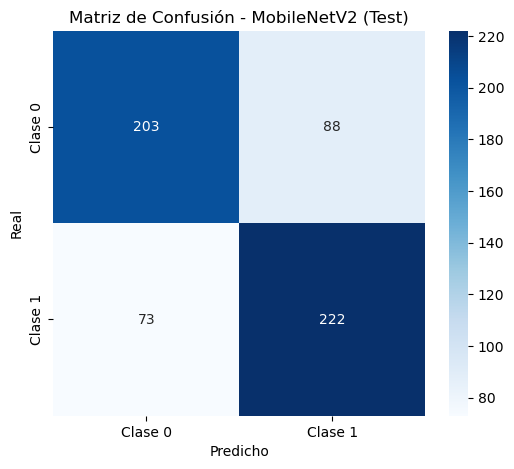

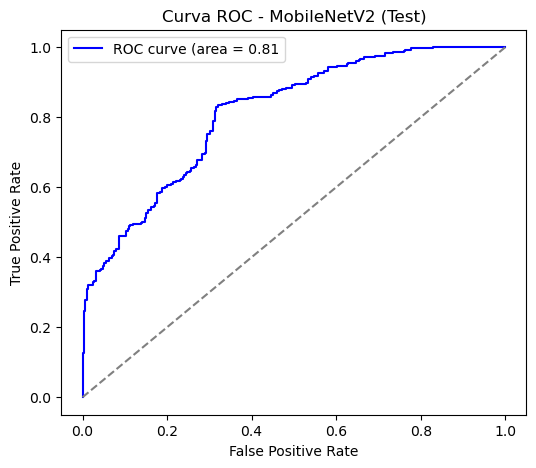

Imágenes clasificadas como falsos positivos en Test: [  2   3   4   5   6   7   8  11  12  13  16  17  21  22  25  26  28  29
  31  32  35  37  42  44  45  49  52  56  58  62  65  66  71  74  77  85
  89  95  96  97  98 102 104 111 123 125 130 131 135 136 140 150 152 156
 161 168 169 174 175 184 185 186 187 198 199 200 203 204 205 206 207 208
 209 210 211 215 216 220 228 232 233 245 251 252 263 270 281 287]
Imágenes clasificadas como falsos negativos en Test: [298 306 323 324 331 336 346 348 349 352 357 370 391 393 398 404 405 407
 408 411 418 419 424 428 432 442 448 454 466 470 471 477 478 482 483 487
 488 491 493 495 496 498 499 501 502 503 506 508 512 516 519 520 523 526
 527 528 529 530 533 534 536 537 538 541 542 544 545 546 547 548 549 552
 583]
✅ Modelo MobileNetV2 guardado con éxito.

Entrenando modelo: ResNet34
Epoch 1/10
43/43 [==============================] - 175s 4s/step - loss: 0.7123 - accuracy: 0.5445 - val_loss: 0.6658 - val_accuracy: 0.6382
Epoch 2/10
43/43 [=========

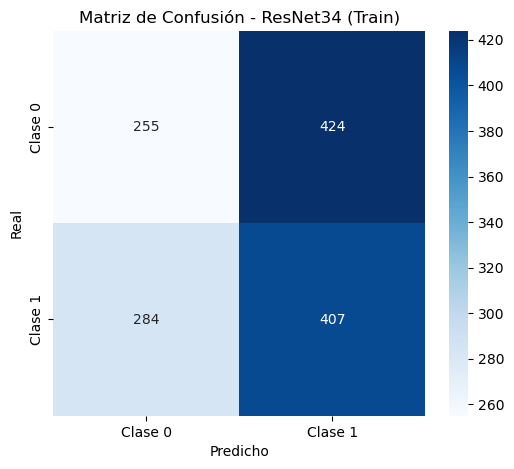

Imágenes clasificadas como falsos positivos en Train: [  2   3   4   5   8   9  10  12  14  17  18  21  22  23  24  25  27  28
  29  31  32  35  36  38  39  40  41  43  44  45  50  51  52  53  54  55
  60  61  65  66  69  70  72  73  75  76  77  79  80  84  86  89  94  96
  97  99 102 105 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 121 123 124 125 126 127 128 129 131 133 134 136 138 140 141 142 143 144
 145 146 147 149 150 154 155 157 158 159 160 161 162 164 165 166 167 170
 172 174 176 178 179 181 182 183 184 185 186 187 188 189 190 191 192 193
 194 195 197 198 201 202 205 211 214 215 218 219 220 222 223 224 226 227
 228 230 231 232 234 235 237 240 241 242 243 246 248 251 252 254 255 257
 258 259 260 266 267 268 270 272 274 275 276 277 278 279 282 284 285 288
 289 292 295 296 297 298 300 302 304 307 309 310 313 315 316 318 320 321
 323 324 325 326 327 328 329 332 333 334 335 337 338 339 342 344 345 346
 347 349 350 351 352 354 357 359 360 362 363 364 365 367 368 369 372 3

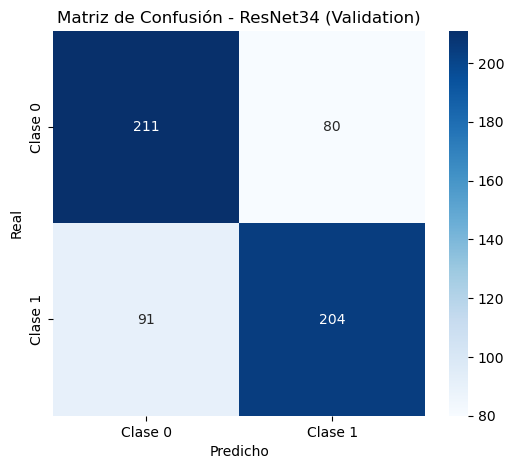

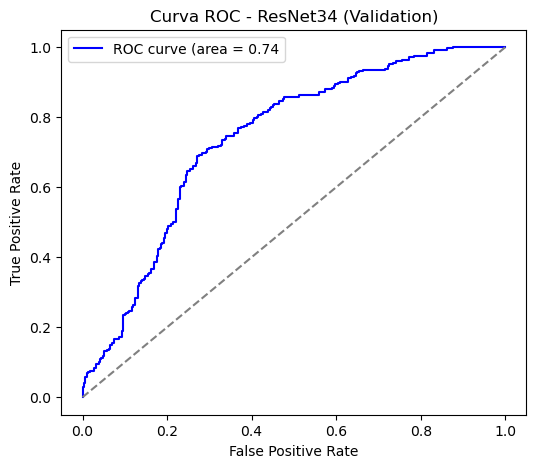

Imágenes clasificadas como falsos positivos en Validation: [  2   3   4   5   6   7   8  11  12  13  16  17  20  21  22  25  26  29
  31  32  35  37  39  41  42  48  49  52  56  58  61  62  64  66  67  68
  69  71  77  85  89  94  96  98 102 104 116 122 123 130 132 135 140 150
 156 161 163 164 184 185 186 200 207 208 210 214 215 216 220 222 225 228
 231 232 233 251 252 255 279 280]
Imágenes clasificadas como falsos negativos en Validation: [292 293 298 306 311 318 319 323 324 328 331 336 343 349 352 360 363 366
 368 369 370 374 376 378 383 386 391 403 404 405 406 407 408 409 410 411
 414 415 417 418 419 428 431 435 442 448 452 454 456 461 462 466 468 470
 471 475 476 477 478 480 482 483 487 488 492 493 495 496 498 499 501 502
 503 507 508 509 510 511 512 513 516 517 518 519 520 522 523 552 554 582
 584]

Evaluando métricas para ResNet34 en Test...
19/19 [==============================] - 52s 3s/step
Matriz de Confusión en Test:
[[211  80]
 [ 91 204]]
Reporte de Clasificación:
         

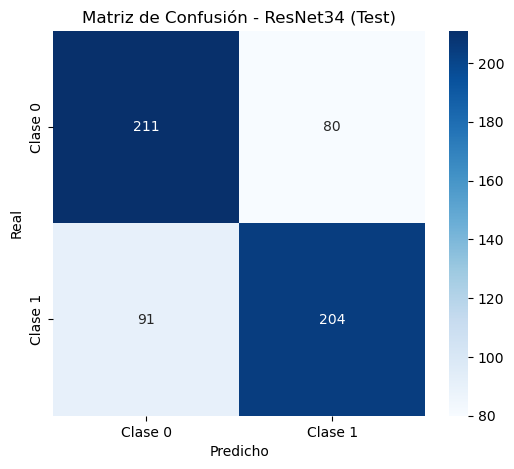

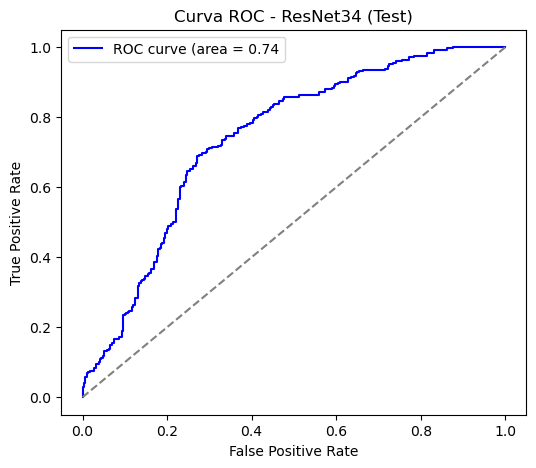

Imágenes clasificadas como falsos positivos en Test: [  2   3   4   5   6   7   8  11  12  13  16  17  20  21  22  25  26  29
  31  32  35  37  39  41  42  48  49  52  56  58  61  62  64  66  67  68
  69  71  77  85  89  94  96  98 102 104 116 122 123 130 132 135 140 150
 156 161 163 164 184 185 186 200 207 208 210 214 215 216 220 222 225 228
 231 232 233 251 252 255 279 280]
Imágenes clasificadas como falsos negativos en Test: [292 293 298 306 311 318 319 323 324 328 331 336 343 349 352 360 363 366
 368 369 370 374 376 378 383 386 391 403 404 405 406 407 408 409 410 411
 414 415 417 418 419 428 431 435 442 448 452 454 456 461 462 466 468 470
 471 475 476 477 478 480 482 483 487 488 492 493 495 496 498 499 501 502
 503 507 508 509 510 511 512 513 516 517 518 519 520 522 523 552 554 582
 584]
✅ Modelo ResNet34 guardado con éxito.

Entrenando modelo: VGG16bn
Epoch 1/10
43/43 [==============================] - 266s 6s/step - loss: 0.6225 - accuracy: 0.7518 - val_loss: 0.8073 - val_accurac

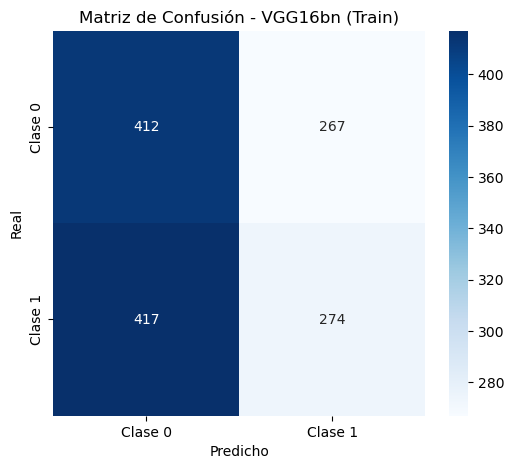

Imágenes clasificadas como falsos positivos en Train: [  3   6   7  12  23  27  29  30  32  33  35  39  40  41  46  47  52  53
  56  60  61  69  70  76  77  80  83  84  92  93  94 102 103 105 106 107
 108 109 110 116 121 123 125 127 128 129 130 131 132 137 138 140 141 148
 153 156 159 161 164 166 168 169 170 171 172 173 175 179 180 182 184 185
 186 187 191 192 194 196 199 200 207 208 211 214 219 221 228 231 232 233
 235 236 237 238 243 244 245 248 249 255 259 263 266 267 274 276 280 281
 283 286 290 291 293 294 299 301 304 306 307 311 313 316 319 320 324 325
 327 329 331 334 335 339 340 341 342 344 345 348 349 351 354 356 359 363
 364 365 366 369 370 372 380 390 391 392 394 395 396 397 398 400 403 405
 406 408 413 420 425 427 428 431 437 440 443 447 448 452 455 459 460 461
 464 466 468 478 483 484 485 489 491 494 496 502 503 504 507 509 510 511
 516 517 519 521 522 524 526 530 531 533 536 538 543 544 545 548 549 552
 554 555 558 559 562 565 571 572 573 577 579 584 589 594 595 598 601 6

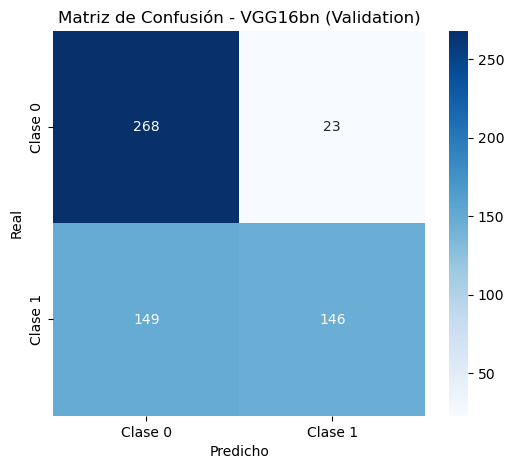

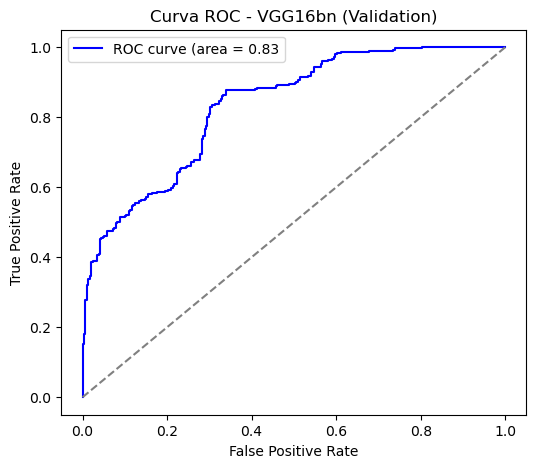

Imágenes clasificadas como falsos positivos en Validation: [ 11  16  35  42  58  62  71  77  89  96 102 111 131 136 150 156 161 184
 186 192 215 220 252]
Imágenes clasificadas como falsos negativos en Validation: [291 292 293 304 306 309 310 311 315 317 322 323 324 328 331 336 343 347
 348 349 352 356 357 360 363 365 367 368 369 370 371 374 375 376 377 378
 383 391 397 398 399 400 404 405 407 408 411 412 415 418 419 424 425 428
 431 432 435 438 442 443 445 448 454 455 456 457 458 459 461 463 465 466
 468 470 471 472 474 475 477 478 479 480 482 483 487 488 491 492 493 494
 495 496 497 498 499 501 502 503 506 507 508 509 510 511 512 516 518 519
 520 522 523 526 527 528 529 530 531 532 533 534 535 536 537 538 539 540
 541 542 543 544 545 546 547 548 549 550 551 552 553 554 559 569 573 574
 575 577 579 583 584]

Evaluando métricas para VGG16bn en Test...
19/19 [==============================] - 75s 4s/step
Matriz de Confusión en Test:
[[268  23]
 [149 146]]
Reporte de Clasificación:
      

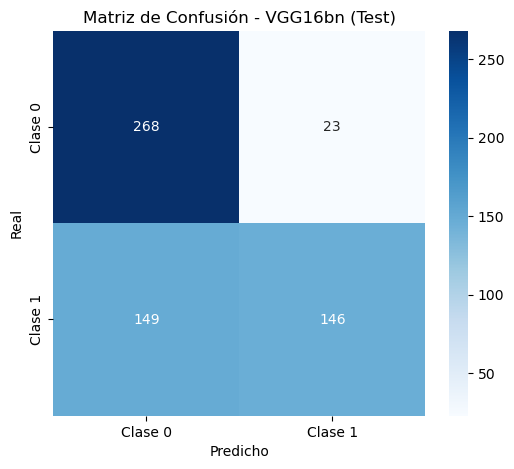

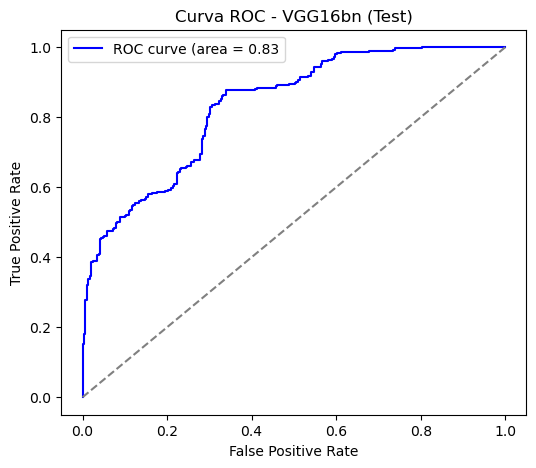

Imágenes clasificadas como falsos positivos en Test: [ 11  16  35  42  58  62  71  77  89  96 102 111 131 136 150 156 161 184
 186 192 215 220 252]
Imágenes clasificadas como falsos negativos en Test: [291 292 293 304 306 309 310 311 315 317 322 323 324 328 331 336 343 347
 348 349 352 356 357 360 363 365 367 368 369 370 371 374 375 376 377 378
 383 391 397 398 399 400 404 405 407 408 411 412 415 418 419 424 425 428
 431 432 435 438 442 443 445 448 454 455 456 457 458 459 461 463 465 466
 468 470 471 472 474 475 477 478 479 480 482 483 487 488 491 492 493 494
 495 496 497 498 499 501 502 503 506 507 508 509 510 511 512 516 518 519
 520 522 523 526 527 528 529 530 531 532 533 534 535 536 537 538 539 540
 541 542 543 544 545 546 547 548 549 550 551 552 553 554 559 569 573 574
 575 577 579 583 584]
✅ Modelo VGG16bn guardado con éxito.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Parámetros
img_size = (224, 224)  
batch_size = 32
epochs = 10
data_dir = r"C:\Users\jupap\OneDrive\Documentos\TesisCami\ProyectoGradoGEB\imagenes_diarias"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (70%), validación (20%) y prueba (10%)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)

train_generator = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size, class_mode="binary", subset="training")
val_generator = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size, class_mode="binary", subset="validation", shuffle=False)
test_generator = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size, class_mode="binary", subset="validation", shuffle=False)

print(f"Total imágenes en entrenamiento: {train_generator.samples}")
print(f"Total imágenes en validación: {val_generator.samples}")
print(f"Total imágenes en prueba: {test_generator.samples}")

# Función para construir modelos
def build_model(base_model):
    base_model.trainable = False  
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    model = build_model(base_model)  
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(train_generator, validation_data=val_generator, epochs=epochs)
    #hoa
    # Evaluar en conjunto de prueba
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Evaluar métricas en cada conjunto
    for dataset_name, generator in zip(["Train", "Validation", "Test"], [train_generator, val_generator, test_generator]):
        print(f"\nEvaluando métricas para {name} en {dataset_name}...")
        y_true = generator.classes
        y_pred_proba = model.predict(generator)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        matriz_conf = confusion_matrix(y_true, y_pred)
        print(f"Matriz de Confusión en {dataset_name}:")
        print(matriz_conf)
        print("Reporte de Clasificación:")
        print(classification_report(y_true, y_pred))
        
        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted')
        print(f"F1-Score: {f1}")
        print(f"Precisión: {precision}")
        
        # Graficar Matriz de Confusión
        plt.figure(figsize=(6, 5))
        sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
        plt.xlabel("Predicho")
        plt.ylabel("Real")
        plt.title(f"Matriz de Confusión - {name} ({dataset_name})")
        plt.show()
        
        # Graficar curva ROC para validación y prueba
        if dataset_name in ["Validation", "Test"]:
            fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(6, 5))
            plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f}')
            plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'Curva ROC - {name} ({dataset_name})')
            plt.legend()
            plt.show()
        
        # Listar imágenes clasificadas incorrectamente
        falsos_positivos = np.where((y_true == 0) & (y_pred == 1))[0]
        falsos_negativos = np.where((y_true == 1) & (y_pred == 0))[0]
        
        print(f"Imágenes clasificadas como falsos positivos en {dataset_name}:", falsos_positivos)
        print(f"Imágenes clasificadas como falsos negativos en {dataset_name}:", falsos_negativos)
    
    # Guardar el modelo
    model.save(f"modelo_anomalias_diario_v2_{name}.h5")  
    print(f"✅ Modelo {name} guardado con éxito.")